Extracting the learning set and test set from the .txt file that generated during eucildean distance

In [16]:
seed_value = 0

In [1]:

def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
        
            # Start capturing when we see the header
            if line.startswith("L set:"):
                capture = True
                continue
        
            # Stop capturing when we reach the B vector
            if line.startswith("B vector:"):
                capture = False
                break
            
            # If we are in the capture zone and the line looks like a list
            if capture and line.startswith("["):
                # ast.literal_eval safely converts the string "[1, 2...]" into a Python list
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

Remember not to change the seed value, it is really important to get the exact result everytime, without changing the model's parameters. Without seed, every run gives different result thought the parameters are same. 

In [2]:
import numpy as np
import ast #abstract syntax tree module for safe evaluation of string.
import random
loaded_train_test_data = []
#first we loading the L set from 2003 to 2023
filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
loaded_learning_data = np.array(extract_L_set(filePath))
random.seed(seed_value)
np.random.seed(seed_value)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#separate the training_validation for Feature and Target
X = loaded_learning_data[:, :5] #first five col of the row is feature
y = loaded_learning_data[:, 5] # 6th value is the target

#split for train and val
X_train = X[30:]
X_val = X[:30]
y_train = y[30:]
y_val = y[:30]

scaler =  StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f"Shape of X_train {X_train.shape}")
print(f"Shape of y_train{y_train.shape}")
print(f"Shape of X_val{X_val.shape}")
print(f"Shape of y_val{y_val.shape}")

Shape of X_train (115, 5)
Shape of y_train(115,)
Shape of X_val(30, 5)
Shape of y_val(30,)


It is time to define the test data from **2024 to 2025**.

In [4]:
loaded_test_data = []
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
loaded_test_data = np.array(extract_L_set(test_filepath))
X_test = loaded_test_data[:, :5]
y_test = loaded_test_data[:, 5]

X_test = scaler.transform(X_test)


Now we are going to make a Feed Forward Neural Network, which has input layer with 5 feature, a hidden layer with initial neuron size 10 with signmoid function, and a signle neuron output layer with linear function.

In [5]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
tf.random.set_seed(seed_value)

# ffnn's parameters
h_neurons = 16
l_rate = 0.001
epoch_size = 30
b_size = 8

#Create a model
ffnn = Sequential()
# Input layer (5 features)
ffnn.add(Input(shape=(X_train.shape[1],)))

ffnn.add(Dense(units=16, activation="relu",))
ffnn.add(Dense(units=1, activation="linear"))
ffnn.summary()


I0000 00:00:1778187739.829392  420744 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778187739.885004  420744 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778187741.216283  420744 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1778187741.875614  420744 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

Now compile and run the model

ModelCheckpoint is a callback function to help to save the model's configuration during every epoch.

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

checkpoint = ModelCheckpoint(
    filepath='models/model_epoch_{epoch:03d}.keras',
    save_weights_only=False,
    verbose=0
    
)

ffnn.compile(optimizer=Adam(learning_rate=l_rate), loss='mse')
ffnn_history = ffnn.fit(X_train, y_train, epochs=epoch_size, batch_size=b_size, verbose=0, callbacks=[checkpoint])
print("Model compiled and trained successfully.")

Model compiled and trained successfully.


After trained the model, we are going to check and evaluate these 200 configs based on the validation set, using "correct directional percentage change". 
The best model configuratoion will be saved which gives biggest correct directional percentage change on the validation data set.

In [7]:
import os
import numpy as np

best_val_acc = -1
best_model_path = ""

def direction_accuracy(y_true, y_pred):
    true_sign = tf.sign(y_true)
    pred_sign = tf.sign(y_pred)
    matches = tf.equal(true_sign, pred_sign)
    return tf.reduce_mean(tf.cast(matches, tf.float32)) * 100

# Loop through all 200 saved models
for epoch in range(1, epoch_size+1):
    model_path = f'models/model_epoch_{epoch:03d}.keras'
    
    # Load the specific epoch configuration
    temp_model = tf.keras.models.load_model(
        model_path, 
        custom_objects={'direction_accuracy': direction_accuracy}
    )
    temp_model.compile(loss='mse', metrics=[direction_accuracy])
    
    # Evaluate on Validation Set
    results = temp_model.evaluate(X_val, y_val, verbose=0)
    val_acc = results[1]
    
    print(f"Epoch {epoch}: Val Direction Acc = {val_acc:.2f}%")
    
    # Check if this is new "Best"
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_path = model_path

print(f"\nBest Config found at: {best_model_path} with {best_val_acc:.2f}%")

Epoch 1: Val Direction Acc = 50.44%
Epoch 2: Val Direction Acc = 49.56%
Epoch 3: Val Direction Acc = 48.67%
Epoch 4: Val Direction Acc = 48.22%
Epoch 5: Val Direction Acc = 47.33%
Epoch 6: Val Direction Acc = 46.89%
Epoch 7: Val Direction Acc = 46.89%
Epoch 8: Val Direction Acc = 47.33%
Epoch 9: Val Direction Acc = 47.33%
Epoch 10: Val Direction Acc = 47.33%
Epoch 11: Val Direction Acc = 46.89%
Epoch 12: Val Direction Acc = 46.89%
Epoch 13: Val Direction Acc = 46.89%
Epoch 14: Val Direction Acc = 46.89%
Epoch 15: Val Direction Acc = 46.89%
Epoch 16: Val Direction Acc = 46.89%
Epoch 17: Val Direction Acc = 46.89%
Epoch 18: Val Direction Acc = 46.89%
Epoch 19: Val Direction Acc = 47.33%
Epoch 20: Val Direction Acc = 47.33%
Epoch 21: Val Direction Acc = 47.33%
Epoch 22: Val Direction Acc = 47.33%
Epoch 23: Val Direction Acc = 47.33%
Epoch 24: Val Direction Acc = 47.33%
Epoch 25: Val Direction Acc = 47.33%
Epoch 26: Val Direction Acc = 47.33%
Epoch 27: Val Direction Acc = 47.33%
Epoch 28: 

In here, we are going to select that best model, and evaluate the **prediction** against validation set.

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf

best_model = tf.keras.models.load_model(best_model_path, compile=False)


y_val_pred = best_model.predict(X_val)

y_val_actual = np.ravel(y_val)
y_val_pred_flat = np.ravel(y_val_pred)

val_direction_match = (np.sign(y_val_actual) == np.sign(y_val_pred_flat)).astype(int)

val_results_df = pd.DataFrame({
    'Actual': y_val_actual,
    'Predicted': y_val_pred_flat,
    'Direction': val_direction_match
})

val_neg_match = ((val_results_df['Actual'] < 0) & (val_results_df['Predicted'] < 0)).sum()

# Count where actual > 0 AND predicted > 0  (positive match)
val_pos_match = ((val_results_df['Actual'] > 0) & (val_results_df['Predicted'] > 0)).sum()

print(f"--- Predictions for Best Model (from {best_model_path}) ---")
print(val_results_df)

final_val_acc = val_results_df['Direction'].mean() * 100
print(f"\nValidation Prediction Accuracy: {final_val_acc:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
--- Predictions for Best Model (from models/model_epoch_001.keras) ---
      Actual  Predicted  Direction
0   0.449403  -0.153546          0
1  -1.033273   0.011192          0
2  -1.028040   0.194247          0
3  -1.118594  -0.314277          1
4   0.304173  -0.697211          0
5   0.237958   0.100808          1
6  -0.179998   0.125186          0
7  -1.305160  -0.750527          1
8   1.118788   0.800890          1
9  -0.404159   0.195108          0
10  0.274649  -0.014264          0
11  0.105960   0.751926          1
12  0.726266   0.045048          1
13 -0.662117   0.817348          0
14 -0.114420  -0.578324          1
15 -0.238144  -0.255594          1
16 -0.521055  -0.195917          1
17  0.064410  -0.170859          0
18 -0.177229  -0.432810          1
19 -0.075720   0.190837          0
20 -0.691956   0.026698          0
21 -0.058821   0.241871          0
22 -0.192841   0.084448          0
23 -0.885929  -0.280781          1
24  0.297621  -0

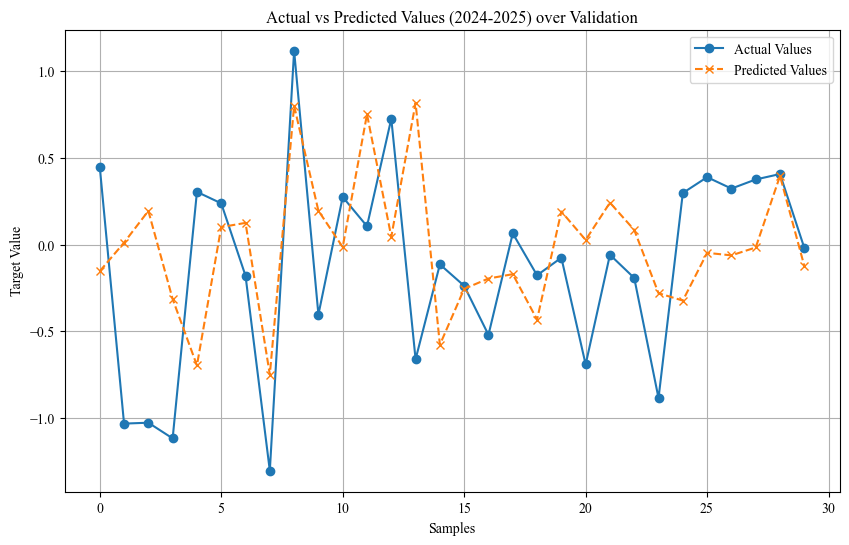

In [9]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_val_actual)), y_val_actual, label="Actual Values", marker="o")
plt.plot(range(len(y_val_pred_flat)), y_val_pred_flat, label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025) over Validation")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

Again, load that best model for final evaluation with the test set.

In [10]:
# Load the best model
final_model = tf.keras.models.load_model(
    best_model_path, 
    custom_objects={'direction_accuracy': direction_accuracy},
    compile=False
)
final_model.compile(
    optimizer='adam',
    loss='mse', 
    metrics=[direction_accuracy]
)


test_results = final_model.evaluate(X_test, y_test, verbose=1)

print("-" * 30)
print(f"FINAL TEST SET PERFORMANCE")
print(f"Direction Accuracy: {test_results[1]:.2f}%")
print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - direction_accuracy: 50.4132 - loss: 0.1029
------------------------------
FINAL TEST SET PERFORMANCE
Direction Accuracy: 50.41%
------------------------------


Get the prediction against test set.

In [11]:

y_pred = final_model.predict(X_test)


y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(y_pred)


direction_match = (np.sign(y_test_flat) == np.sign(y_pred_flat)).astype(int)

import pandas as pd

results_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': y_pred_flat,
    'Direction': direction_match
})
test_neg_match = ((results_df['Actual'] < 0) & (results_df['Predicted'] < 0)).sum()

# Count where actual > 0 AND predicted > 0  (positive match)
test_pos_match = ((results_df['Actual'] > 0) & (results_df['Predicted'] > 0)).sum()

print(results_df)
final_test_acc = results_df['Direction'].mean() * 100
print(f"\nTest Prediction Accuracy: {final_test_acc:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
      Actual  Predicted  Direction
0  -0.017473  -0.006986          1
1  -0.339443  -0.373986          1
2   0.031541   0.066199          1
3  -0.215161   0.369991          0
4  -0.087107  -0.080599          1
5   0.485383   0.043420          1
6  -0.220254   0.248546          0
7   0.307394   0.335859          1
8   0.306878  -0.085950          0
9   0.113420   0.198828          1
10  0.198257  -0.259123          0

Test Prediction Accuracy: 63.64%


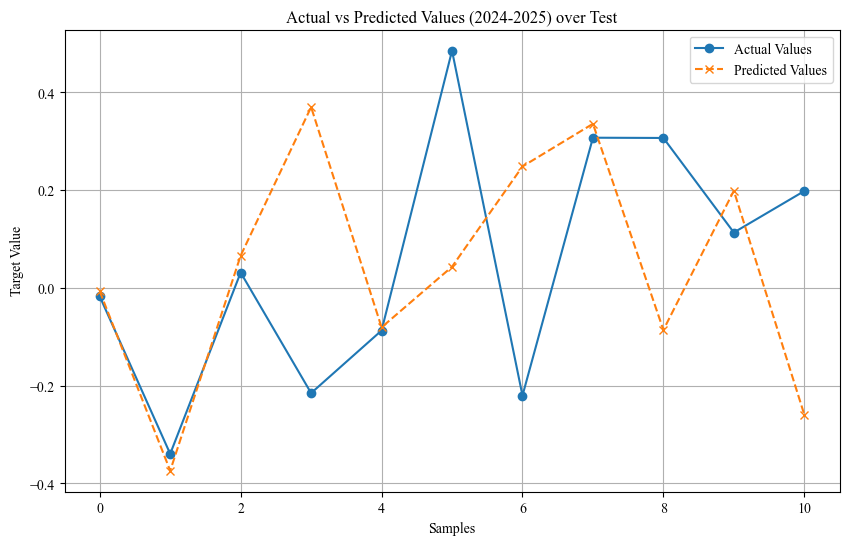

In [12]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test_flat)), y_test_flat, label="Actual Values", marker="o")
plt.plot(range(len(y_pred_flat)), y_pred_flat, label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025) over Test")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import pandas as pd
import os

def append_result_pd(seed, val_pct, test_pct, val_pos, val_neg, test_pos, test_neg,
                     filepath="seed_result/results.csv"):
    # Create folder if it doesn't exist
    folder = os.path.dirname(filepath)
    if folder:
        os.makedirs(folder, exist_ok=True)

    # Build the new row as a list of strings (exactly what will be written)
    new_row_values = [str(seed), str(val_pct), str(test_pct),
                      str(val_pos), str(val_neg), str(test_pos), str(test_neg)]

    # Check for existing duplicate if the file already exists
    if os.path.isfile(filepath) and os.path.getsize(filepath) > 0:
        existing = pd.read_csv(filepath, dtype=str)   # read all as strings to match formatting
        # Compare the new row (as string) against every existing row
        duplicate = (existing == new_row_values).all(axis=1).any()
        if duplicate:
            print(f"Duplicate row for seed={seed} found – skipping append.")
            return   # exit without writing

    # Write header only if the file doesn't exist yet
    header = not os.path.isfile(filepath) or os.path.getsize(filepath) == 0

    df = pd.DataFrame(
        [new_row_values],
        columns=["seed", "val %", "test %", "val (+)", "val(-)", "test(+)", "test(-)"]
    )
    df.to_csv(filepath, mode='a', header=header, index=False)
    print(f"Seed {seed} saved.")
append_result_pd(seed_value, f"{final_val_acc:.2f}", f"{final_test_acc:.2f}", val_pos_match, val_neg_match, test_pos_match, test_neg_match)

Seed 0 saved.
